In [46]:
from pathlib import Path
import re
import matplotlib.pyplot as plt


def extract_train_losses(file_path, scale=1000):
    file_path = Path(file_path)

    with open(file_path, "r", encoding="utf-8", errors="replace") as f:
        text = f.read()

    train_losses = [
        float(match.group(1)) * scale
        for match in re.finditer(r"Train Loss:\s*([0-9.eE+-]+)", text)
    ]

    return train_losses


def clean_label(file_name):
    return Path(file_name).name.replace(".log", "").replace("_", " ").replace("att", "attention,")


def plot_train_losses(file_names, scale=1000):
    plt.figure(figsize=(9, 5))

    for file_name in file_names:
        train_losses = extract_train_losses(file_name, scale=scale)

        if len(train_losses) == 0:
            print(f"Warning: no train losses found in {file_name}")
            continue

        epochs = range(1, len(train_losses) + 1)
        plt.plot(epochs, train_losses, label=clean_label(file_name))

    plt.xlabel("Epoch", fontsize=14)
    plt.ylabel(r"Train MSE loss [$10^{-3}$]", fontsize=14)
    plt.title("Train loss comparison", fontsize=14)

    plt.ylim(14,20)

    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)

    plt.legend(fontsize=14)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

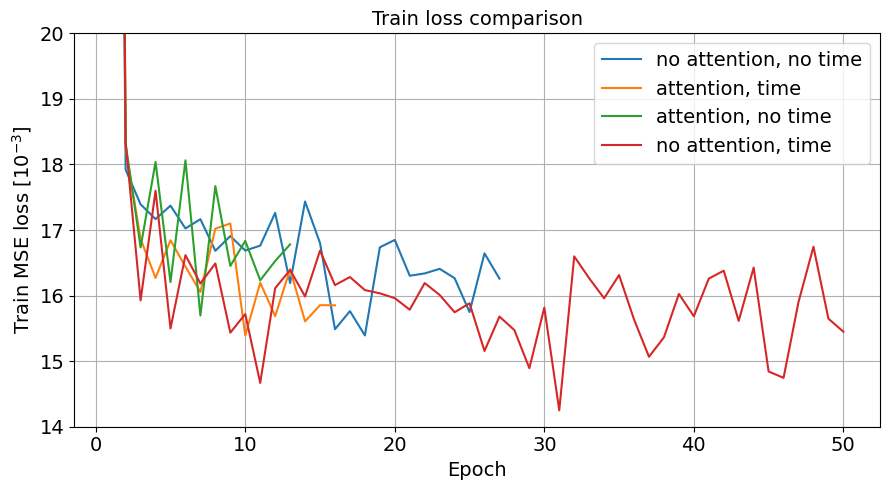

In [47]:
file_names = [
    "no_att_no_time.log",
   "att_time.log",
    "att_no_time.log",
    "no_att_time.log"
]


plot_train_losses(file_names)